In [6]:
# Complete Linear Regression Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load dataset
dataset = fetch_california_housing()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df["Target"] = dataset.target

# Split features and target
X = df.drop("Target", axis=1)
y = df["Target"]

# Train, Test & Split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2-Score: {r2}")

Mean Absolute Error: 0.5332001304956564
Mean Squared Error: 0.5558915986952444
Root Mean Squared Error: 0.7455813830127764
R2-Score: 0.5757877060324508


## Laaso Regression

In [2]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

Lasso=Lasso()

paramter=parameters = {
    "alpha": np.logspace(-4, 1, 50)
}

lassocv=GridSearchCV(Lasso,paramter)
lassocv.fit(X_train,y_train)

GridSearchCV(estimator=Lasso(),
             param_grid={'alpha': array([1.00000000e-04, 1.26485522e-04, 1.59985872e-04, 2.02358965e-04,
       2.55954792e-04, 3.23745754e-04, 4.09491506e-04, 5.17947468e-04,
       6.55128557e-04, 8.28642773e-04, 1.04811313e-03, 1.32571137e-03,
       1.67683294e-03, 2.12095089e-03, 2.68269580e-03, 3.39322177e-03,
       4.29193426e-03, 5.42867544e-03, 6.86648845e-03, 8.68511...
       2.81176870e-02, 3.55648031e-02, 4.49843267e-02, 5.68986603e-02,
       7.19685673e-02, 9.10298178e-02, 1.15139540e-01, 1.45634848e-01,
       1.84206997e-01, 2.32995181e-01, 2.94705170e-01, 3.72759372e-01,
       4.71486636e-01, 5.96362332e-01, 7.54312006e-01, 9.54095476e-01,
       1.20679264e+00, 1.52641797e+00, 1.93069773e+00, 2.44205309e+00,
       3.08884360e+00, 3.90693994e+00, 4.94171336e+00, 6.25055193e+00,
       7.90604321e+00, 1.00000000e+01])})

In [3]:
print(lassocv.best_params_)
print(lassocv.best_score_)

{'alpha': 0.0006551285568595509}
0.6115034456562827


In [4]:
lasso_pred=lassocv.predict(X_test)

In [5]:
# Evaluation Metrics
mse = mean_squared_error(y_test, lasso_pred)
mae = mean_absolute_error(y_test, lasso_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lasso_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R2-Score: {r2}")

Mean Absolute Error: 0.5331589179972245
Mean Squared Error: 0.5549581025845478
Root Mean Squared Error: 0.7449551010527734
R2-Score: 0.5765000760834784


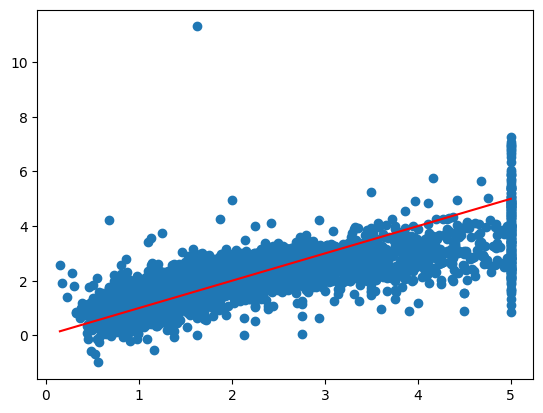

In [7]:
plt.scatter(y_test, lasso_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')  # ideal line